<a href="https://colab.research.google.com/github/Meemansha-spec/EDA-with-Pandas/blob/main/Churn_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
churn_data = pd.read_csv('/content/telecom_customer_churn_cleaned.csv')

In [ ]:
churn_data = churn_data[churn_data['customer_status'].isin(['Stayed','Churned'])]

In [ ]:
churn_data['churned']  = churn_data['customer_status'].apply(lambda x: 1 if x == 'Churned' else 0)

#### Tenure Groups

In [ ]:
bins = [0,12,24,36,48,72]
labels = ['0-12','13-24','25-36','37-48','48+']
churn_data['tenure_group'] = pd.cut(churn_data['tenure_in_months'],bins=bins,labels=labels)

In [ ]:
print( "=" * 55)
print( "Telecom Churn Dashboard - The Full Story")
print( "=" * 55)

Telecom Churn Dashboard - The Full Story


# Plot 1: Contract Type - Who is at more Risk?
### Which contract should we push customers towards?

In [ ]:
contract_churn = churn_data.groupby('contract')['churned'].mean() * 100
contract_churn = contract_churn.reset_index()
contract_churn.columns = ['contract_type','churn_rate_%']
contract_churn = contract_churn.sort_values('churn_rate_%',ascending=False)

In [ ]:
contract_churn

,contract_type,churn_rate_%
0,Month-to-Month,51.686446
1,One Year,10.878113
2,Two Year,2.579258


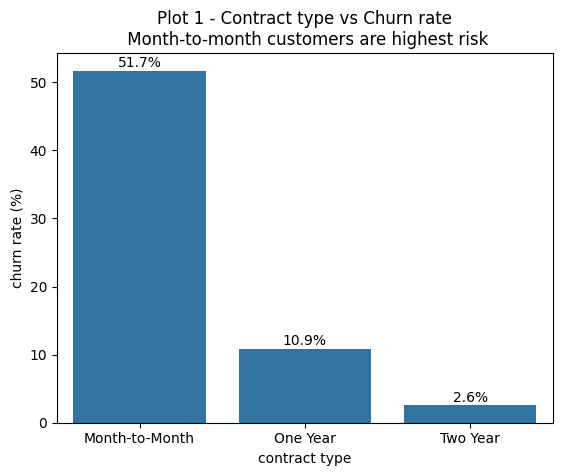

In [ ]:
sns.barplot(data=contract_churn, x='contract_type', y='churn_rate_%')
plt.title('Plot 1 - Contract type vs Churn rate\n Month-to-month customers are highest risk')
plt.xlabel('contract type')
plt.ylabel('churn rate (%)')

for i , row in contract_churn.reset_index().iterrows():

 plt.text(i, row['churn_rate_%'] + 0.5, f"{row['churn_rate_%']:.1f}%", ha='center', fontsize=10)
plt.show()

# Plot 2 - When Do they leave?

## When should we intervene to save the customer?


In [ ]:
churn_by_tenure = churn_data.groupby('tenure_group')['churned'].mean() * 100
churn_by_tenure = churn_by_tenure.reset_index()
churn_by_tenure.columns = ['tenure_group','churn_rate_%']
churn_by_tenure

/tmp/ipykernel_2811/3907458215.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = churn_data.groupby('tenure_group')['churned'].mean() * 100


,tenure_group,churn_rate_%
0,0-12,59.872979
1,13-24,28.710938
2,25-36,21.634615
3,37-48,19.028871
4,48+,9.513176


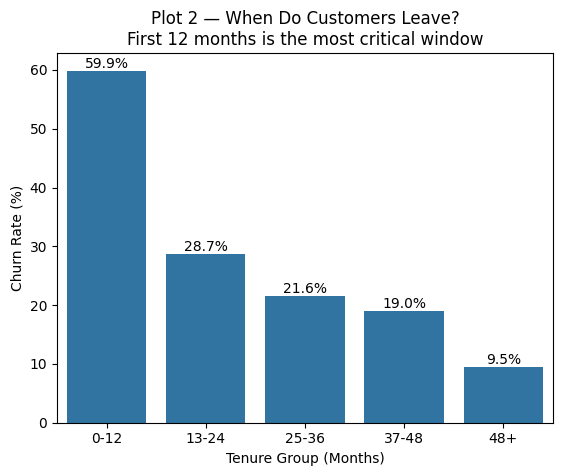

In [ ]:
sns.barplot(data = churn_by_tenure , x = 'tenure_group' , y = 'churn_rate_%')
plt.title('Plot 2 — When Do Customers Leave?\nFirst 12 months is the most critical window')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Churn Rate (%)')
for i, row in churn_by_tenure.reset_index().iterrows():
    plt.text(i, row['churn_rate_%'] + 0.5, f"{row['churn_rate_%']:.1f}%", ha='center', fontsize=10)
plt.show()

# Plot 3 - Why did they leave?
## Is churn a product problem or a people problem?

In [ ]:
category_counts = churn_data['churn_category'].value_counts().reset_index()
category_counts.columns = ['churn_category','count']
category_counts

,churn_category,count
0,Not Churned,4720
1,Competitor,841
2,Dissatisfaction,321
3,Attitude,314
4,Price,211
5,Other,182


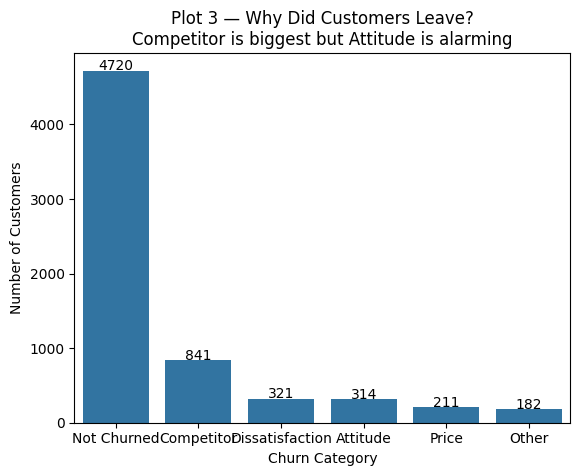

In [ ]:
sns.barplot(data=category_counts, x='churn_category', y='count')
plt.title('Plot 3 — Why Did Customers Leave?\nCompetitor is biggest but Attitude is alarming')
plt.xlabel('Churn Category')
plt.ylabel('Number of Customers')
for i, row in category_counts.reset_index().iterrows():
    plt.text(i, row['count'] + 5, str(row['count']), ha='center', fontsize=10)
plt.show()

# ── Plot 4: Specific Reasons — Top 10 ────────────────────────
## Business question: What exactly needs fixing?

In [ ]:
top_reasons = churn_data['churn_reason'].value_counts().head(10).reset_index()
top_reasons.columns = ['churn_reason','count']
top_reasons

,churn_reason,count
0,Not Churned,4720
1,Competitor had better devices,313
2,Competitor made better offer,311
3,Attitude of support person,220
4,Don't know,130
5,Competitor offered more data,117
6,Competitor offered higher download speeds,100
7,Attitude of service provider,94
8,Price too high,78
9,Product dissatisfaction,77


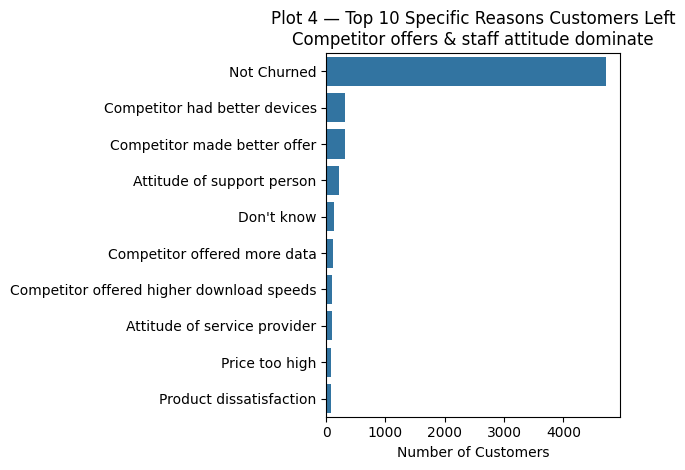

In [ ]:
sns.barplot(data=top_reasons, x='count', y='churn_reason')
plt.title('Plot 4 — Top 10 Specific Reasons Customers Left\nCompetitor offers & staff attitude dominate')
plt.xlabel('Number of Customers')
plt.ylabel('')
plt.tight_layout()
plt.show()

# ── Plot 5: Referral Churn Rate — Loyalty Signal ─────────────
## Business question: Does a referral program reduce churn?

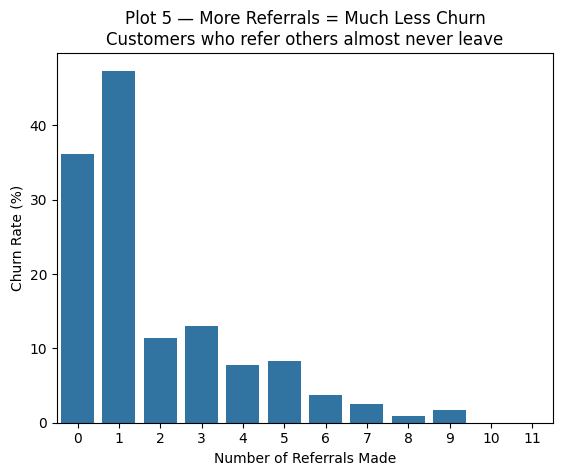

In [ ]:
churn_by_referral = churn_data.groupby('number_of_referrals')['churned'].mean() * 100
churn_by_referral = churn_by_referral.reset_index()
churn_by_referral.columns = ['number_of_referrals', 'churn_rate_%']

sns.barplot(data=churn_by_referral, x='number_of_referrals', y='churn_rate_%')
plt.title('Plot 5 — More Referrals = Much Less Churn\nCustomers who refer others almost never leave')
plt.xlabel('Number of Referrals Made')
plt.ylabel('Churn Rate (%)')
plt.show()

# ── Plot 6: Feature Correlation — Early Warning Signals ───────
## Business question: What signals tell us a customer is about to leave?

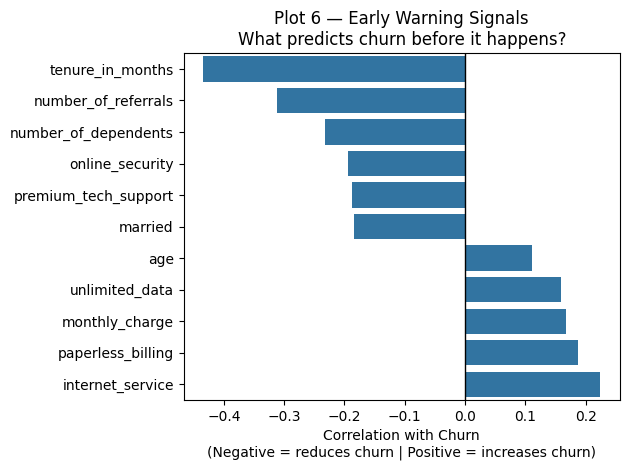

In [ ]:
important_features = [
    'tenure_in_months', 'number_of_referrals',
    'monthly_charge', 'number_of_dependents',
    'online_security', 'premium_tech_support',
    'married', 'age', 'internet_service',
    'paperless_billing', 'unlimited_data'
]

correlations = churn_data[important_features + ['churned']].corr()['churned'].drop('churned').sort_values()

sns.barplot(x=correlations.values, y=correlations.index)
plt.title('Plot 6 — Early Warning Signals\nWhat predicts churn before it happens?')
plt.xlabel('Correlation with Churn\n(Negative = reduces churn | Positive = increases churn)')
plt.ylabel('')
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()
